# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [141]:
# Data Import

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.preprocessing import StandardScaler

alldata = pd.read_excel("alldata.xlsx")
drdata = pd.read_excel("drdata.xlsx")
drq = pd.read_excel("drq.xlsx")
tv2data = pd.read_excel("tv2data.xlsx")
tv2q = pd.read_excel("tv2q.xlsx")
electeddata = pd.read_excel("electeddata.xlsx")

In [142]:
alldata


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,1,1,1,-2,2,-1,1,-2,1,1,...,1,2,-1,2,1,-2,0,0,Københavns Omegns Storkreds,33
863,1,-2,-2,-2,1,-2,-1,-2,-2,-2,...,-1,0,-1,2,2,-2,0,0,Københavns Omegns Storkreds,45
864,1,1,1,-2,2,-1,1,-1,-1,1,...,-1,0,-1,2,2,-2,0,1,Københavns Omegns Storkreds,52
865,1,-1,1,-2,1,-1,-1,-1,-1,1,...,0,0,0,2,1,-2,1,0,Københavns Omegns Storkreds,44


In [143]:
drdata


,530,531,533,534,535,537,538,540,541,543,...,552,553,555,556,557,559,561,563,navn,parti
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,-2,2,2,1,2,2,-2,Lars Philipsen Prahm,Moderaterne
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,1,1,-1,-2,1,2,1,2,Karsten Hønge,Socialistisk Folkeparti
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,2,-1,-2,-1,1,2,2,2,Martin Kelleher-Petersen,Alternativet
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,1,2,-2,2,2,2,2,Nicklas Gjedsig Larsen,Alternativet
4,1,1,-2,2,-2,1,-2,1,2,-2,...,2,-2,-2,-1,1,-2,-1,-2,Tom Gillesberg,Løsgænger
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
899,1,1,1,-2,2,-1,1,-2,1,1,...,-1,1,1,-2,2,0,2,1,Maria Gudme,Socialdemokratiet
900,1,-2,-2,-2,1,-2,-1,-2,-2,-2,...,2,1,-1,-2,2,2,-1,1,Maria Durhuus,Socialdemokratiet
901,1,1,1,-2,2,-1,1,-1,-1,1,...,1,2,2,-2,1,1,1,1,Morten Bødskov,Socialdemokratiet
902,1,-1,1,-2,1,-1,-1,-1,-1,1,...,1,-1,1,-2,1,1,1,1,Jeppe Bruus,Socialdemokratiet


In [144]:
drq

,ID,Title,Question,Info,ArgumentFor,ArgumentAgainst,WordMerger,ID_CandidateQuestionType,Rule,QuestionListData
0,530,KLIMA OG ENERGI,Danmark skal bruge flere penge på at styrke to...,NaN,Den kollektive trafik bør være billig og tilgæ...,Det er dyrt for statskassen at opretholde drif...,0,1,FT,NaN
1,531,ARBEJDSMARKED OG ØKONOMI,Der skal indføres en særlig skat på de allerhø...,NaN,Historisk rammer kriser de fattigste hårdest. ...,Det danske samfund er et af de mest lige samfu...,0,1,FT,NaN
2,533,RET OG STRAF,Kriminalitet begået i udsatte boligområder ska...,NaN,Den mest effektive måde at stoppe bandekrimina...,"Det er urimeligt, at den samme forbrydelse ska...",0,1,FT,NaN
3,534,EU OG UDENRIGS,På sigt skal Danmark meldes ud af EU,NaN,"Så længe Danmark er medlem af EU, kan flertall...",Danmark er bedst tjent med at være en del af E...,0,1,FT,NaN
4,535,EU OG UDENRIGS,"Det er fornuftigt, at Danmark i de kommende år...",NaN,Ruslands angreb på Ukraine har ændret alting o...,Vi er medlemmer af Nato og har i forvejen et s...,0,1,FT,NaN
5,537,VELFÆRD,"Det er okay, at den økonomiske ulighed stiger,...",NaN,Økonomisk ulighed afspejler belønningen den en...,Større økonomisk ulighed vil skævvride samfund...,0,1,FT,NaN
6,538,UDDANNELSE,Forældres indkomst skal være et af kriterierne...,NaN,Det er vigtigt at vores gymnasier består af un...,De unge risikerer at miste pladsen på deres næ...,0,1,FT,NaN
7,540,VELFÆRD,Det skal være muligt at tjene penge på at driv...,NaN,Der er brug for en bred vifte af forskellige d...,Skattekroner tiltænkt velfærd skal ikke kunne ...,0,1,FT,NaN
8,541,ARBEJDSMARKED OG ØKONOMI,Der skal indføres skat på fortjenesten ved sal...,NaN,"Det er kun rimeligt, at man betaler skat af st...","Det er mere sikkert for alle, at boligejere be...",0,1,FT,NaN
9,543,VELFÆRD,"Det er en god idé, at dagpengesatsen for nyudd...",NaN,De fleste nyuddannede er yngre mennesker uden ...,Som nyuddannet er man ofte ved at etablere sig...,0,1,FT,NaN


In [145]:
tv2data

,1a,1b,2a,2b,3a,3b,4a,4b,5a,5b,...,10a,10b,11a,11b,12a,12b,parti,navn,storkreds,alder
0,0,1,1,1,1,-1,0,1,0,0,...,0,2,-1,2,0,0,Venstre,Birthe Tindbæk Bredo,Bornholms Storkreds,63
1,-1,1,0,-1,2,-2,-1,-1,-2,1,...,1,-1,-1,2,1,-1,Venstre,Julie Pauch Nymark,Bornholms Storkreds,27
2,-2,0,0,1,1,-1,0,1,-1,1,...,1,1,-2,2,1,1,Venstre,Peter Juel-Jensen,Bornholms Storkreds,56
3,-2,-1,2,2,2,-2,0,-1,-2,1,...,1,-1,-2,2,2,-2,Dansk Folkeparti,Mette Sode Hansen,Bornholms Storkreds,42
4,-2,-1,1,1,2,-2,1,0,-1,1,...,2,1,-1,2,0,1,Dansk Folkeparti,René Danielsson,Bornholms Storkreds,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
957,2,2,2,2,-2,2,2,-2,-2,1,...,-1,2,-2,2,0,0,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Karina Dammand,Østjyllands Storkreds,42
958,2,2,2,2,-2,2,2,2,-2,-1,...,-2,2,-2,2,-2,-2,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Mohamed Abdikarim,Østjyllands Storkreds,33
959,2,2,2,2,-2,2,2,1,-2,0,...,1,2,-1,2,1,1,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Niko Grünfeld,Østjyllands Storkreds,47
960,1,2,2,1,-2,1,2,0,-1,0,...,2,1,-2,2,1,0,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Sara Hvidbak Grouleff,Østjyllands Storkreds,33


In [146]:
tv2q

,id,type,header,question,depends
0,bornholm-1,rate,Bornholms Storkreds,Med særligt attraktive vilkår bør staten sikre...,{'selectedArea': 'bornholms storkreds'}
1,bornholm-2,rate,Bornholms Storkreds,"Staten bør sørge for, at flytrafikken til og f...",{'selectedArea': 'bornholms storkreds'}
2,bornholm-3,rate,Bornholms Storkreds,Der skal sættes flere penge af til Forsvarets ...,{'selectedArea': 'bornholms storkreds'}
3,bornholm-4,rate,Bornholms Storkreds,Det skal være lettere at hente udenlandsk arbe...,{'selectedArea': 'bornholms storkreds'}
4,bornholm-5,rate,Bornholms Storkreds,Beslutningen om at etablere en naturnationalpa...,{'selectedArea': 'bornholms storkreds'}
...,...,...,...,...,...
69,10b,rate,Socialområdet,"Den såkaldte Arne-pension, der giver mulighed ...",NaN
70,11a,rate,Mink-sagen,Der har været alt for meget fokus på Mette Fre...,NaN
71,11b,rate,Mink-sagen,"Det bør undersøges, om Mette Frederiksen kan s...",NaN
72,12a,rate,Coronavirus,"Hvis coronasmitten stiger markant til vinter, ...",NaN


In [147]:
electeddata

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
1,2,2,-2,-2,-2,-2,2,2,2,-2,...,-2,0,-2,2,1,1,0,-2,Østjyllands Storkreds,58
2,2,2,-2,-1,-1,-1,1,-2,2,-2,...,-2,0,-1,2,0,-2,-1,1,Østjyllands Storkreds,30
3,-1,-1,2,-1,2,-1,-2,1,-2,1,...,-1,-1,0,2,-2,2,0,0,Østjyllands Storkreds,53
4,-1,-1,1,-2,2,1,-2,1,-2,1,...,-1,0,1,1,-2,2,1,-1,Østjyllands Storkreds,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,1,1,2,-2,2,-1,1,-1,-1,1,...,0,-1,1,2,1,-2,1,0,Københavns Omegns Storkreds,41
165,1,1,1,-2,2,-1,1,-1,-1,1,...,-1,0,-1,2,1,-2,1,1,Københavns Omegns Storkreds,33
166,1,-2,-2,-2,1,-2,-1,-2,-2,-2,...,-1,0,-1,2,2,-2,0,0,Københavns Omegns Storkreds,45
167,1,1,1,-2,2,-1,1,-1,-1,1,...,-1,0,-1,2,2,-2,0,1,Københavns Omegns Storkreds,52


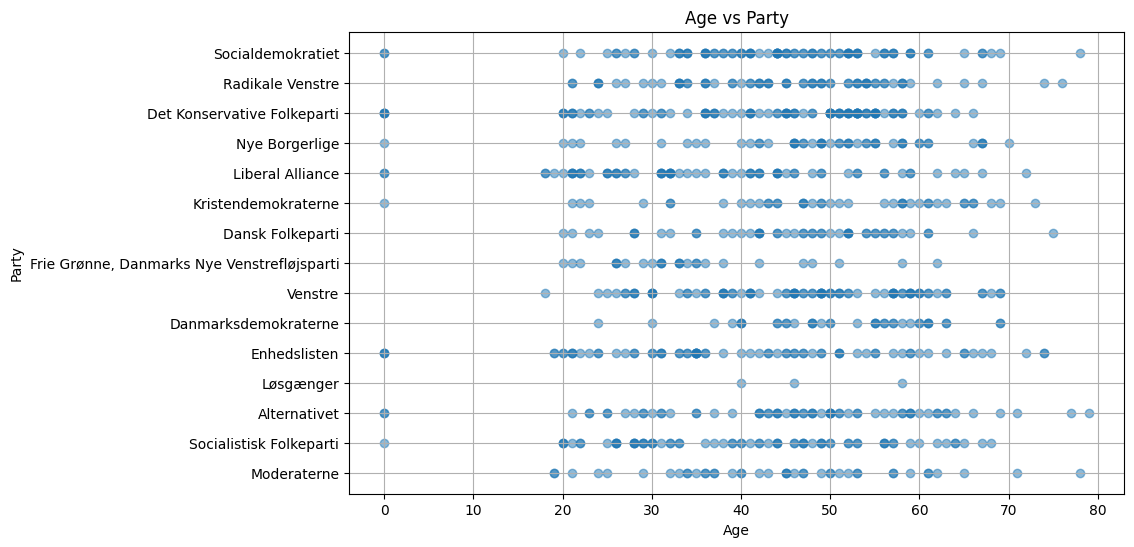

In [148]:
# age and party

plt.figure(figsize=(10, 6))
plt.scatter(alldata["alder"], alldata["parti"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Party")
plt.title("Age vs Party")
plt.grid()
plt.show()

In [149]:
#confident candidates
# An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.

alldata.isna().sum()

def confidence_score(row):
    return ((row == 2) | (row == -2)).mean()

question_cols = [col for col in alldata.columns if col.startswith("q")]

alldata["confidence"] = alldata[question_cols].apply(confidence_score, axis=1)

alldata.sort_values("confidence", ascending=False)[["navn", "parti", ]].head(10)

,navn,parti
0,Lars Philipsen Prahm,Moderaterne
1,Karsten Hønge,Socialistisk Folkeparti
2,Martin Kelleher-Petersen,Alternativet
3,Nicklas Gjedsig Larsen,Alternativet
4,Tom Gillesberg,Løsgænger
5,Jan Kristoffersen,Alternativet
6,Johan Kahl,Moderaterne
7,Thor Clasen Jonasen,Alternativet
8,Chresten H. Ibsen,Løsgænger
9,Vinni Kjærgaard Jørgensen,Alternativet


['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds', 'alder', 'confidence']
Numeriske kolonner: ['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'alder', 'confidence']
Spørgsmålskolonner: ['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5

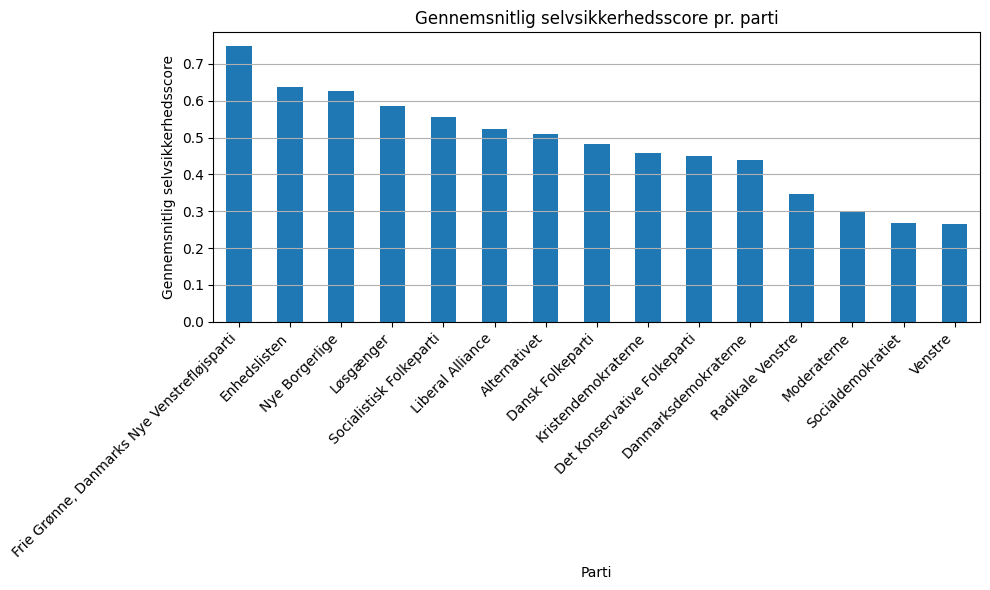

In [150]:
#Et parti hvor de har flest der har stærkte holdninger -2 eller 2... ekstra analyse


print(alldata.columns.tolist())


numeric_cols = alldata.select_dtypes(include="number").columns.tolist()
print("Numeriske kolonner:", numeric_cols)

question_cols = [col for col in numeric_cols if col not in ["alder", "confidence"]]
print("Spørgsmålskolonner:", question_cols)

def confidence_score(row):
    valid = row.dropna()
    if len(valid) == 0:
        return np.nan
    return valid.isin([2, -2]).mean()

alldata["confidence"] = alldata[question_cols].apply(confidence_score, axis=1)

print(alldata["confidence"].head())
print(alldata["confidence"].describe())

party_confidence = (
    alldata.groupby("parti")["confidence"]
    .mean()
    .sort_values(ascending=False)
)

print(party_confidence)

plt.figure(figsize=(10, 6))
party_confidence.plot(kind="bar")
plt.xlabel("Parti")
plt.ylabel("Gennemsnitlig selvsikkerhedsscore")
plt.title("Gennemsnitlig selvsikkerhedsscore pr. parti")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [151]:
from sklearn.model_selection import train_test_split

# vælg spørgsmålskolonner (tilpas hvis dine hedder noget andet)
question_cols = [col for col in alldata.columns if col.startswith("spm")]

X = alldata[question_cols]
y = alldata["parti"]

# fjern rækker med missing
data = alldata.dropna(subset=question_cols + ["parti"])

X = data[question_cols]
y = data["parti"]

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [152]:
# Se kolonnerne
print(alldata.columns.tolist())

# Vælg numeriske kolonner
numeric_cols = alldata.select_dtypes(include=np.number).columns.tolist()
print("Numeriske kolonner:", numeric_cols)

# Fjern kolonner der ikke er spørgsmål
exclude_cols = ["confidence", "alder"]
question_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Spørgsmålskolonner:", question_cols)
print("Antal spørgsmålskolonner:", len(question_cols))

# Behold kun rækker med parti og mindst nogle gyldige svar
data = alldata.dropna(subset=["parti"]).copy()

X = data[question_cols]
y = data["parti"]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Hvis der stadig mangler værdier i spørgsmålene:
X = X.fillna(X.median(numeric_only=True))

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# 1. Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("Decision Tree accuracy:", accuracy_score(y_test, dt_pred))

# 2. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

# 3. Gradient Boosted Tree
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting accuracy:", accuracy_score(y_test, gb_pred))

['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds', 'alder', 'confidence']
Numeriske kolonner: ['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a', '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'alder', 'confidence']
Spørgsmålskolonner: ['530', '531', '533', '534', '535', '537', '538', '540', '541', '543', '544', '545', '546', '547', '548', '550', '551', '552', '553', '555', '556', '557', '559', '561', '563', '1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b', '5a', '5

In [153]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))

Random Forest accuracy: 0.9272030651340997


In [154]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting accuracy:", accuracy_score(y_test, gb_pred))

Gradient Boosting accuracy: 0.8467432950191571


In [155]:
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting:", accuracy_score(y_test, gb_pred))

Decision Tree: 0.7624521072796935
Random Forest: 0.9272030651340997
Gradient Boosting: 0.8467432950191571


In [156]:
best_model = rf_model

data["predicted_party"] = best_model.predict(X)

wrong_party = data[data["parti"] != data["predicted_party"]]

wrong_party[["navn", "parti", "predicted_party"]].head(10)

,navn,parti,predicted_party
3,Nicklas Gjedsig Larsen,Alternativet,Socialdemokratiet
8,Chresten H. Ibsen,Løsgænger,Radikale Venstre
42,Ali Khatib,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet
43,Sara Hvidbak Grouleff,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet
89,Per Urban Olsen,Det Konservative Folkeparti,Kristendemokraterne
92,Anders Krojgaard Lund,Det Konservative Folkeparti,Liberal Alliance
139,Linea Søgaard-Lidell,Venstre,Det Konservative Folkeparti
219,Nikoline Prehn,Socialdemokratiet,Socialistisk Folkeparti
250,Phillip Sperling,Venstre,Liberal Alliance
289,Alexander Klitgaard,Det Konservative Folkeparti,Liberal Alliance


In [157]:

# Find numeriske kolonner
numeric_cols = alldata.select_dtypes(include=np.number).columns.tolist()

# Fjern kolonner der ikke er spørgsmål
exclude_cols = ["confidence"]
question_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Number of question features:", len(question_cols))

# Fjern rækker uden parti
data = alldata.dropna(subset=["parti"]).copy()

X = data[question_cols]
y = data["parti"]

# Udfyld manglende værdier
X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training observations:", X_train.shape)
print("Test observations:", X_test.shape)

Number of question features: 50
Training observations: (606, 50)
Test observations: (261, 50)


In [158]:


dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree accuracy:", dt_acc)
print(classification_report(y_test, dt_pred))

Decision Tree accuracy: 0.6666666666666666
                                             precision    recall  f1-score   support

                               Alternativet       0.46      0.80      0.58        20
                       Danmarksdemokraterne       0.90      0.82      0.86        11
                           Dansk Folkeparti       0.92      0.80      0.86        15
                Det Konservative Folkeparti       0.82      0.30      0.44        30
                               Enhedslisten       0.88      0.95      0.91        22
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.00      0.00      0.00         8
                        Kristendemokraterne       1.00      0.46      0.63        13
                           Liberal Alliance       0.71      0.81      0.76        21
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       0.00      0.00      0.00        13
                     

c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

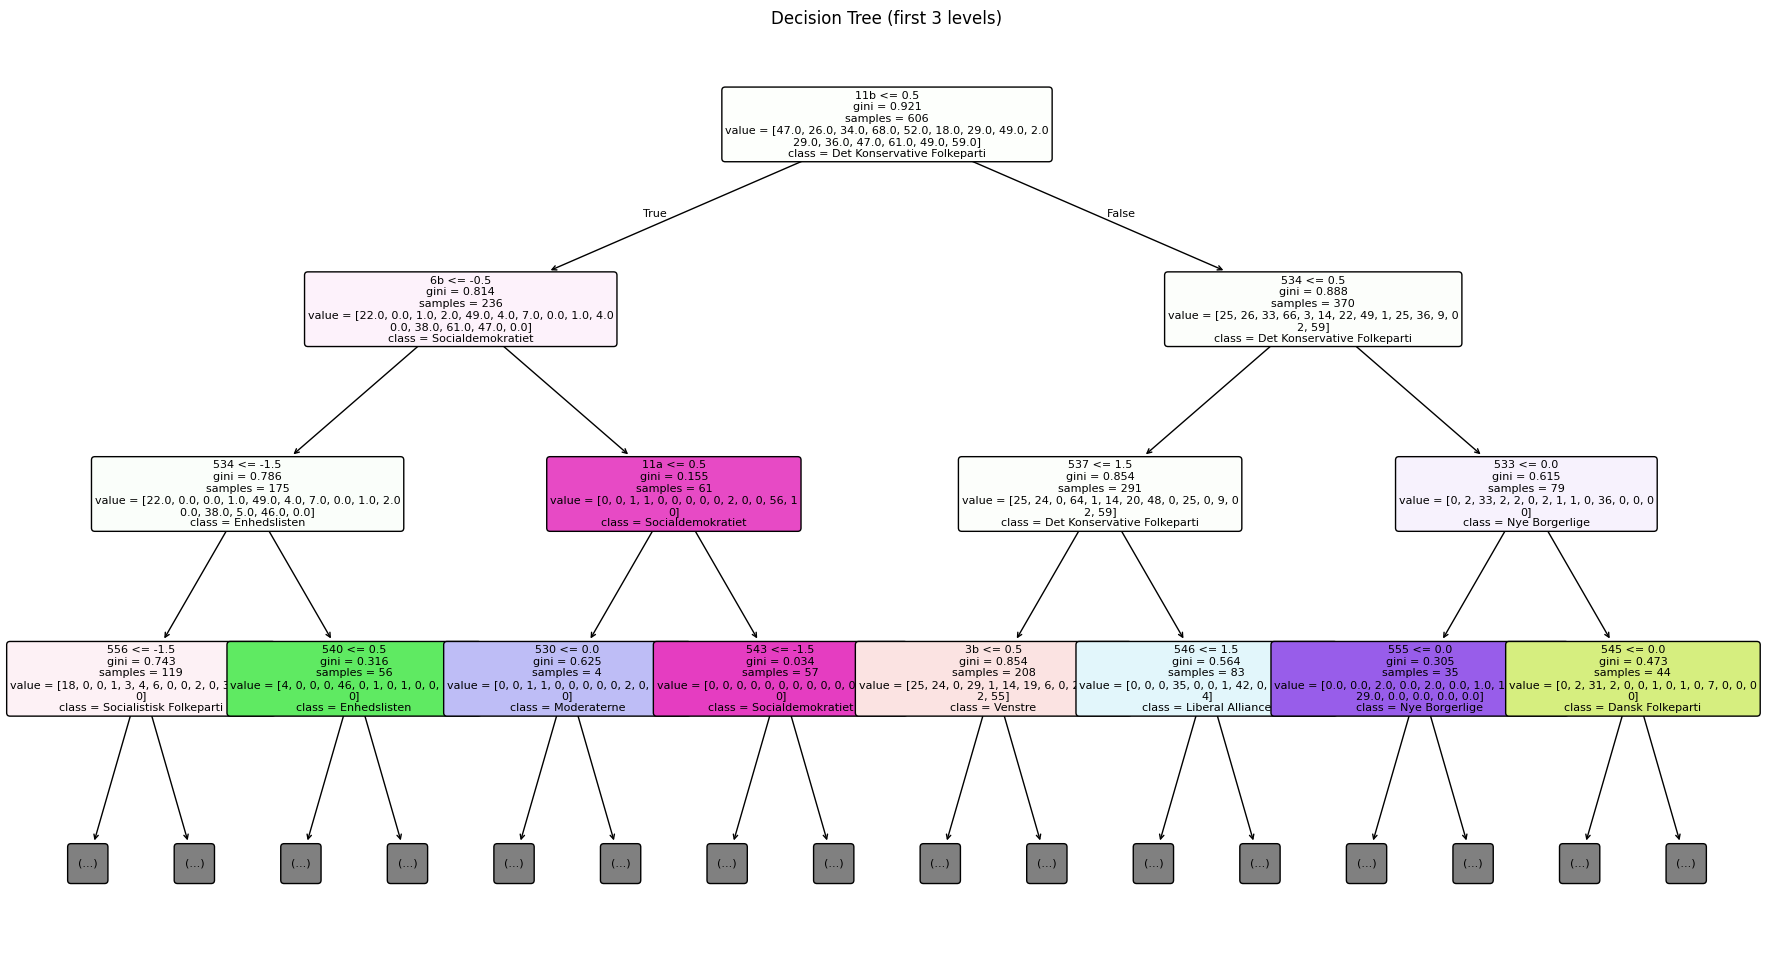

In [159]:
plt.figure(figsize=(22,12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree (first 3 levels)")
plt.show()

In [160]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

Random Forest accuracy: 0.9157088122605364
                                             precision    recall  f1-score   support

                               Alternativet       0.78      0.90      0.84        20
                       Danmarksdemokraterne       1.00      1.00      1.00        11
                           Dansk Folkeparti       0.93      0.93      0.93        15
                Det Konservative Folkeparti       0.93      0.87      0.90        30
                               Enhedslisten       0.86      0.86      0.86        22
Frie Grønne, Danmarks Nye Venstrefløjsparti       1.00      0.62      0.77         8
                        Kristendemokraterne       0.92      0.92      0.92        13
                           Liberal Alliance       0.87      0.95      0.91        21
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       1.00      1.00      1.00        13
                     

c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

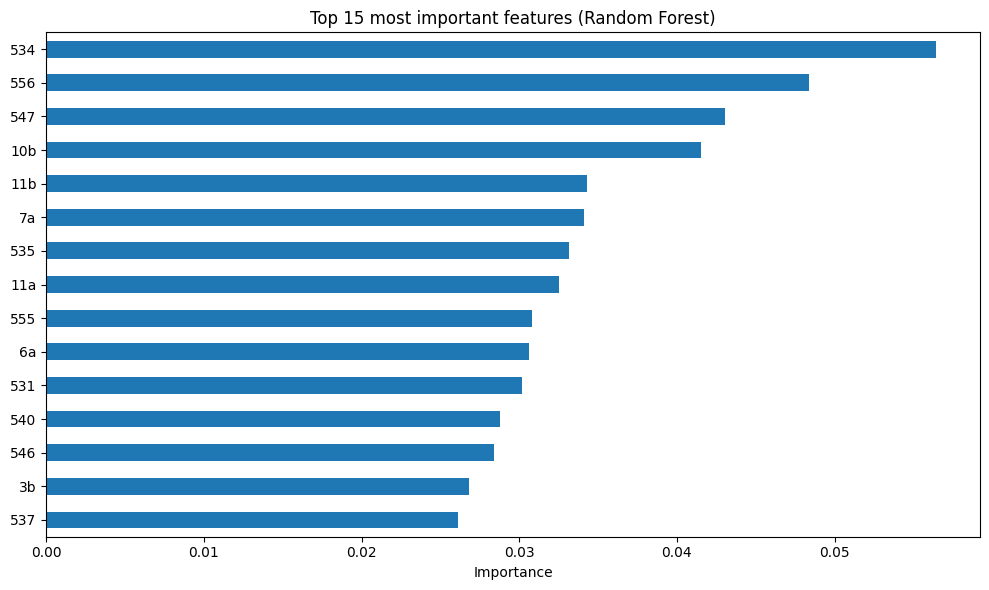

In [161]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

rf_importance = rf_importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
rf_importance.plot(kind="barh")
plt.gca().invert_yaxis()

plt.title("Top 15 most important features (Random Forest)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

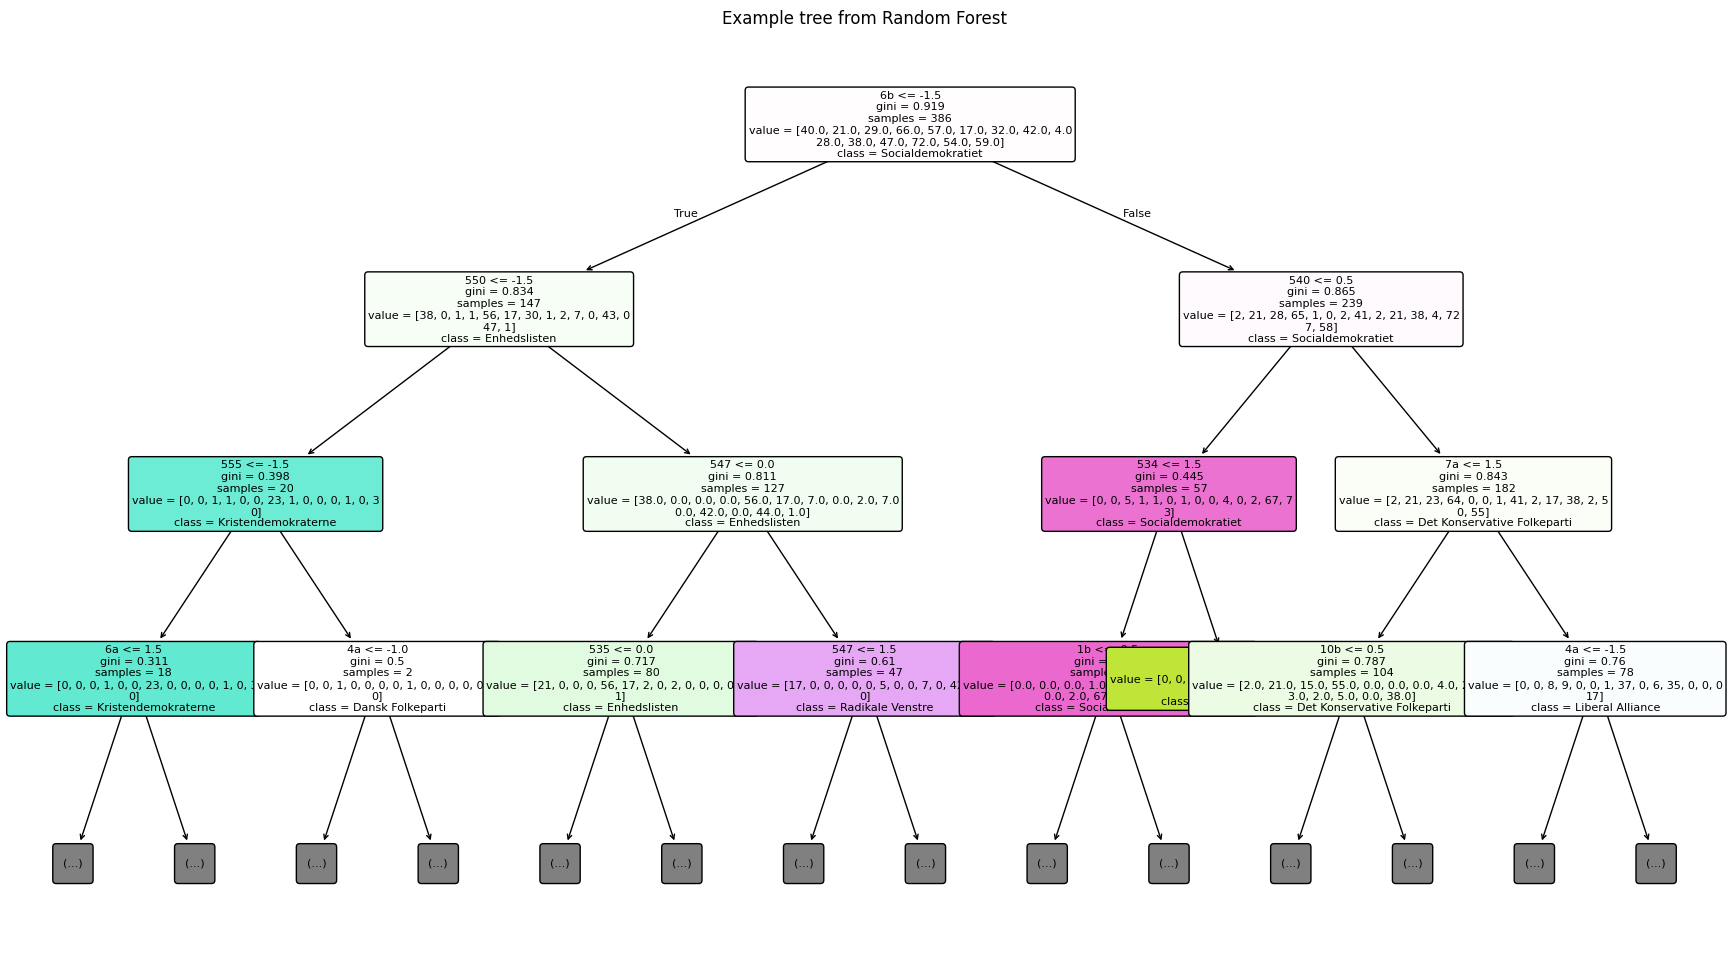

In [162]:
from sklearn.tree import plot_tree

one_tree = rf_model.estimators_[0]

plt.figure(figsize=(22,12))

plot_tree(
    one_tree,
    feature_names=X.columns,
    class_names=rf_model.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Example tree from Random Forest")
plt.show()

In [163]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting accuracy:", gb_acc)
print(classification_report(y_test, gb_pred))

Gradient Boosting accuracy: 0.8467432950191571
                                             precision    recall  f1-score   support

                               Alternativet       0.70      0.80      0.74        20
                       Danmarksdemokraterne       0.90      0.82      0.86        11
                           Dansk Folkeparti       0.87      0.87      0.87        15
                Det Konservative Folkeparti       0.86      0.80      0.83        30
                               Enhedslisten       0.86      0.86      0.86        22
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.75      0.38      0.50         8
                        Kristendemokraterne       0.90      0.69      0.78        13
                           Liberal Alliance       0.84      1.00      0.91        21
                                  Løsgænger       0.00      0.00      0.00         1
                                Moderaterne       0.81      1.00      0.90        13
                 

c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Guffe\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

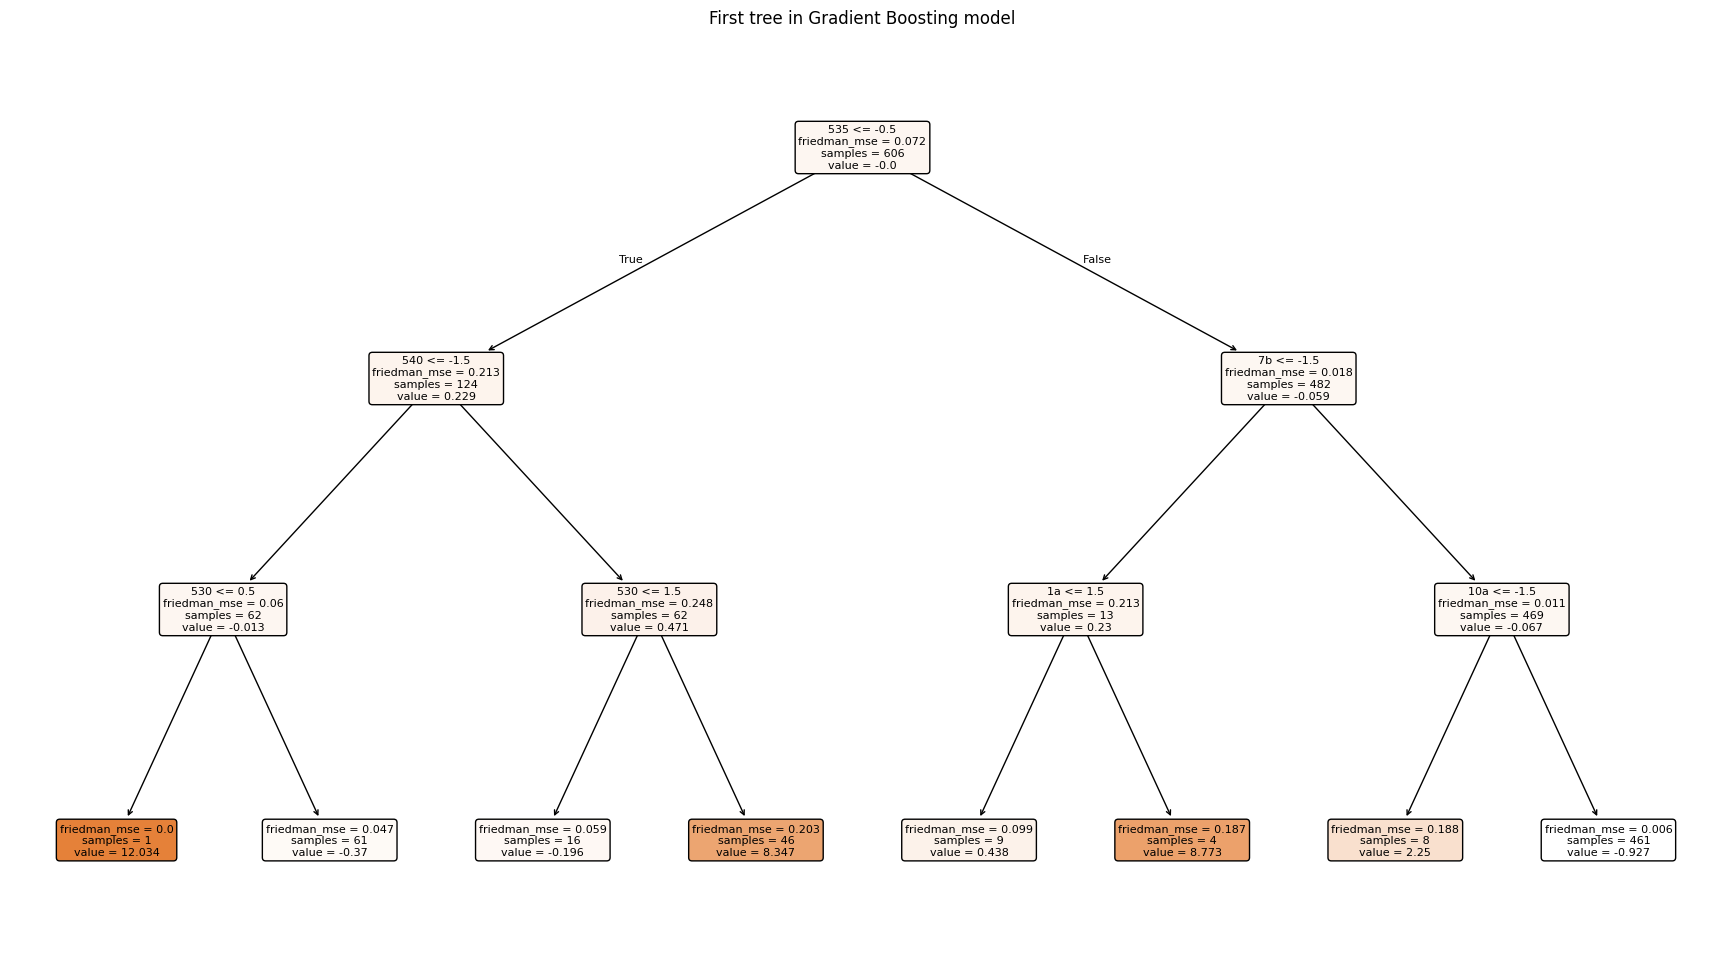

In [164]:
gb_tree = gb_model.estimators_[0,0]

plt.figure(figsize=(22,12))

plot_tree(
    gb_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("First tree in Gradient Boosting model")
plt.show()

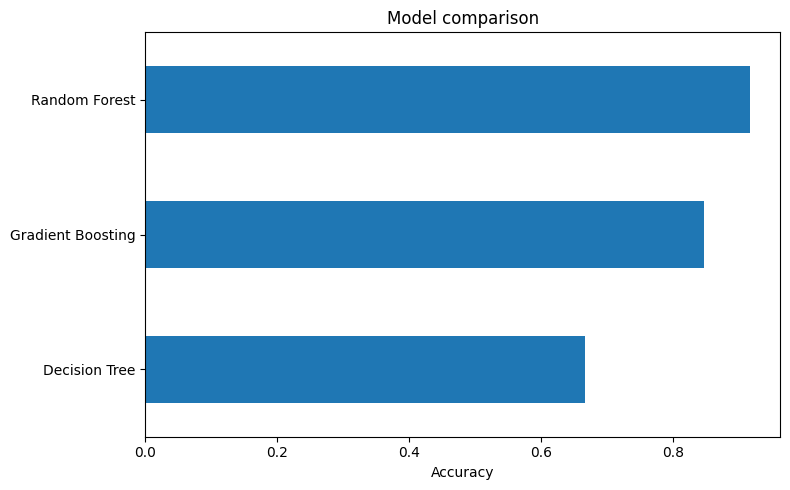

In [165]:
model_scores = pd.Series({
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "Gradient Boosting": gb_acc
})

plt.figure(figsize=(8,5))

model_scores.sort_values().plot(kind="barh")

plt.xlabel("Accuracy")
plt.title("Model comparison")

plt.tight_layout()
plt.show()

In [166]:
best_model = rf_model

data["predicted_party"] = best_model.predict(X)

wrong_party = data[data["parti"] != data["predicted_party"]]

wrong_party[["navn","parti","predicted_party"]].head(15)

,navn,parti,predicted_party
1,Karsten Hønge,Socialistisk Folkeparti,Enhedslisten
3,Nicklas Gjedsig Larsen,Alternativet,Socialdemokratiet
8,Chresten H. Ibsen,Løsgænger,Kristendemokraterne
42,Ali Khatib,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet
43,Sara Hvidbak Grouleff,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Alternativet
65,Michael Valentin Ilsø,Liberal Alliance,Nye Borgerlige
76,Sofie Lippert,Socialistisk Folkeparti,Enhedslisten
92,Anders Krojgaard Lund,Det Konservative Folkeparti,Liberal Alliance
219,Nikoline Prehn,Socialdemokratiet,Socialistisk Folkeparti
250,Phillip Sperling,Venstre,Liberal Alliance
